In [1]:
!pip install \
numpy==1.26.4 \
pandas==2.2.3 \
matplotlib==3.7.2 \
scikit-learn==1.2.2 \
xgboost==2.0.3 \
lightgbm==4.5.0 \
catboost==1.2.8 \
rdkit==2025.3.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 39.6 MB/s eta 0:00:00


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [3]:
# Configs
RANDOM_STATE = 42
N_FOLDS = 5

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11
})

In [4]:
from typing import Dict, List, Tuple

# ───────────────────────── RNG (hard‑wired) ───────────────────────
RANDOM_STATE: int = 42
_rng = np.random.default_rng(RANDOM_STATE)

# ─────────────────── Optional Numba acceleration ──────────────────
try:
    from numba import njit  

    @njit(cache=True, fastmath=True)
    def _best_split_numba(vals, residuals, leaf_idx, lvl, thresholds, l2):
        best_mae = 1e20 #Use MAE objective
        best_thr = thresholds[0]
        n = vals.size
        for t in range(thresholds.size):
            thr = thresholds[t]
            bit = vals > thr
            new_idx = leaf_idx | (bit.astype(np.int32) << lvl)

            cnt = np.zeros(8, dtype=np.int32)         
            ssum = np.zeros(8, dtype=np.float32)
            for i in range(n):
                idx = new_idx[i]
                cnt[idx] += 1
                ssum[idx] += residuals[i]

            mae = 0.0
            for i in range(n):
                idx = new_idx[i]
                pred = ssum[idx] / (cnt[idx] + l2)
                diff = residuals[i] - pred
                mae += np.abs(diff) 

            if mae < best_mae:
                best_mae = mae
                best_thr = thr
        return best_mae, best_thr

    _NUMBA_OK = True
except ImportError:
    _NUMBA_OK = False

# ────────────────────── Oblivious Tree ────────────────────────────
class ObliviousTree:
    DEPTH: int = 3
    L2: float = 1.0
    MAX_FEATS: int = 5            # ≤5 random features / level
    N_BINS: int = 100

    def __init__(self) -> None:
        self._splits: List[Tuple[int, float]] = []
        self._leaf_val: np.ndarray | None = None

    def fit(self, X: np.ndarray, residuals: np.ndarray) -> None:
        n_samples, n_features = X.shape
        leaf_idx = np.zeros(n_samples, dtype=np.int32)

        for lvl in range(self.DEPTH):
            best_mae, best_split = np.inf, None

            # 1. Random‑subspace: at most 5 features
            feat_ids = (
                _rng.choice(n_features, self.MAX_FEATS, replace=False)
                if n_features > self.MAX_FEATS
                else np.arange(n_features)
            )

            for f in feat_ids:
                vals = X[:, f]
                uniq = np.unique(vals)
                if uniq.size == 1:
                    continue

                # 2. Candidate thresholds
                if uniq.size <= self.N_BINS:
                    thresholds = 0.5 * (uniq[:-1] + uniq[1:])
                else:
                    q = np.linspace(0, 1, self.N_BINS+1)[1:-1]        
                    thresholds = np.unique(np.quantile(vals, q))

                if thresholds.size == 0:
                    continue

                # 3. Evaluate thresholds (Numba fast path)
                if _NUMBA_OK:
                    mae, thr = _best_split_numba(
                        vals.astype(np.float32),
                        residuals.astype(np.float32),
                        leaf_idx.copy(),
                        lvl,
                        thresholds.astype(np.float32),
                        self.L2,
                    )
                    if mae < best_mae:
                        best_mae, best_split = mae, (f, float(thr))
                else:
                    for thr in thresholds:
                        bit = (vals > thr).astype(np.int32)
                        new_idx = leaf_idx | (bit << lvl)

                        cnt = np.bincount(new_idx, minlength=new_idx.max() + 1)
                        ssum = np.bincount(
                            new_idx, weights=residuals, minlength=new_idx.max() + 1
                        )
                        pred = ssum / (cnt + self.L2)
        
                        mae = np.sum(np.abs(residuals - pred[new_idx]))
                        if mae < best_mae:
                            best_mae, best_split = mae, (f, thr)

            if best_split is None:
                break

            f_best, thr_best = best_split
            self._splits.append(best_split)
            leaf_idx |= (X[:, f_best] > thr_best).astype(np.int32) << lvl

        # 4. leaf values
        n_leaves = 1 << self.DEPTH
        self._leaf_val = np.zeros(n_leaves, dtype=np.float32)
        cnt = np.bincount(leaf_idx, minlength=n_leaves)
        ssum = np.bincount(leaf_idx, weights=residuals, minlength=n_leaves)
        mask = cnt > 0
        self._leaf_val[mask] = ssum[mask] / (cnt[mask] + self.L2)

    def _leaf_index(self, X: np.ndarray) -> np.ndarray:
        idx = np.zeros(X.shape[0], dtype=np.int32)
        for lvl, (f, thr) in enumerate(self._splits):
            idx |= (X[:, f] > thr).astype(np.int32) << lvl
        return idx

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self._leaf_val is None:
            raise RuntimeError("Tree not fitted.")
        return self._leaf_val[self._leaf_index(X)]

# ─────────────────────── LiteBoost engine ─────────────────────────
class LiteBoost:
    """Gradient boosting with fixed trees; only n_estimators & η exposed."""

    SUBSAMPLE_CAP: int = 300      # ≤300 rows per tree

    def __init__(self, n_estimators: int = 500, learning_rate: float = 0.05) -> None:
        self.n_estimators = int(n_estimators)
        self.learning_rate = float(learning_rate)
        self._trees: List[ObliviousTree] = []

    # -----------------------------------------------------------------
    # Scikit-learn compatibility
    # -----------------------------------------------------------------
    def get_params(self, deep: bool = True) -> dict:
        """Return constructor parameters for grid-search / cloning."""
        return {"n_estimators": self.n_estimators,
                "learning_rate": self.learning_rate}

    # (Optional but handy)
    def set_params(self, **kwargs):
        """Set parameters; returns self for chaining."""
        for k, v in kwargs.items():
            if hasattr(self, k):
                setattr(self, k, v)
        return self
    # -----------------------------------------------------------------
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> "LiteBoost":
        
        global _rng
        _rng = np.random.default_rng(RANDOM_STATE)
        self._trees.clear()
        n_total = X.shape[0]
        pred = np.zeros_like(y)

        for _ in range(self.n_estimators):
            # 1. Compute residuals on all samples
            residuals_full = y - pred

            # 2. Choose a subsample (≤300 rows)
            if n_total > self.SUBSAMPLE_CAP:
                idx = _rng.choice(n_total, self.SUBSAMPLE_CAP, replace=False)
                X_sub = X[idx]
                res_sub = residuals_full[idx]
            else:
                X_sub = X
                res_sub = residuals_full

            # 3. Fit tree, update predictions for all rows
            tree = ObliviousTree()
            tree.fit(X_sub, res_sub)
            pred += self.learning_rate * tree.predict(X)
            self._trees.append(tree)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        total = np.zeros(X.shape[0], dtype=np.float32)
        for tr in self._trees:
            total += self.learning_rate * tr.predict(X)
        return total

In [5]:
# Per model thresholds
MODEL_FILTERS = {
    "LiteBoost":  {"MIN": 0.0710,  "MAX": 0.9780},
    "XGBoost":    {"MIN": 0.0320,  "MAX": 0.97403},
    "LightGBM":   {"MIN": 0.0066,  "MAX": 0.9470},
    "CatBoost":   {"MIN": 0.0460,  "MAX": 0.9840},
    "ExtraTrees": {"MIN": 0.0147,  "MAX": 0.9586},
}

# Models and tuned params
MODELS = {
    "LiteBoost": {"ctor": LiteBoost, "params": {"n_estimators": 961, "learning_rate": 0.11708}},
    "XGBoost":   {"ctor": XGBRegressor, "params": {
        "n_estimators": 756, "learning_rate": 0.0349, "max_depth": 20,
        "min_child_weight": 2.5552, "subsample": 0.6470, "colsample_bytree": 0.5189,
        "gamma": 0.0006, "reg_alpha": 0.0005, "reg_lambda": 4.5627,
        "tree_method": "hist", "objective": "reg:absoluteerror", "random_state": 42
    }},
    "LightGBM":  {"ctor": LGBMRegressor, "params": {
        "n_estimators": 1430, "learning_rate": 0.0105, "max_depth": 8, "num_leaves": 247,
        "min_child_samples": 6, "min_child_weight": 0.0224, "subsample": 0.6136,
        "colsample_bytree": 0.3832, "reg_alpha": 0.0024, "reg_lambda": 0.0918,
        "random_state": 42, "verbose": -1
    }},
    "CatBoost":  {"ctor": CatBoostRegressor, "params": {
        "iterations": 1945, "learning_rate": 0.0421, "depth": 5, "l2_leaf_reg": 3.3589,
        "subsample": 0.5755, "rsm": 0.9212, "bagging_temperature": 0.7092,
        "loss_function": "MAE", "random_seed": 42, "allow_writing_files": False, "verbose": False
    }},
    "ExtraTrees": {"ctor": ExtraTreesRegressor, "params": {
        "n_estimators": 1303, "max_depth": 23, "min_samples_split": 3, "min_samples_leaf": 1,
        "max_features": 0.657, "bootstrap": False, "random_state": 42, "criterion": "absolute_error"
    }},
}

In [6]:
# Helpers
def canonicalise(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles, sanitize=True)
        if mol is None:
            return None
        Chem.Kekulize(mol, clearAromaticFlags=True)
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None

_desc_list = Descriptors.descList if hasattr(Descriptors, "descList") else Descriptors._descList
DESCRIPTOR_FUNCS = {name: fn for name, fn in _desc_list}

def rdkit_descriptors(smiles: str) -> dict:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {name: np.nan for name in DESCRIPTOR_FUNCS}
    return {name: fn(mol) for name, fn in DESCRIPTOR_FUNCS.items()}

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    eps = 1e-12
    resid = y_true - y_pred
    rmse = float(np.sqrt(np.mean(resid**2)))
    mae = float(np.mean(np.abs(resid)))
    medae = float(np.median(np.abs(resid)))
    mape = float(np.mean(np.abs(resid / (y_true + eps))) * 100.0)
    maxe = float(np.max(np.abs(resid)))
    r2 = 1.0 - float(np.sum(resid**2)) / float(np.sum((y_true - y_true.mean())**2))
    ev = 1.0 - float(np.var(resid)) / float(np.var(y_true))
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MedAE": medae, "MAPE": mape, "MaxE": maxe, "EV": ev}

In [7]:
# Data 
DATA_CSV = "/kaggle/input/neurips-open-polymer-prediction-2025/train.csv"
target_name = 'Tg'
df = pd.read_csv(DATA_CSV).dropna(subset=[target_name]).reset_index(drop=True)
df["canonical"] = df["SMILES"].apply(canonicalise)
df = df.dropna(subset=["canonical"]).reset_index(drop=True)
df = df.groupby("canonical", as_index=False).agg({target_name: "mean"})

X_desc = df["canonical"].apply(rdkit_descriptors).apply(pd.Series)
usable = X_desc.notna().any() & (X_desc.nunique(dropna=True) > 1)
X_df = X_desc.loc[:, usable].astype(float)
y = df[target_name].values.astype(float)
print(X_df.shape)

(511, 185)


In [8]:
# Correlations for greedy filtering
abs_rho = X_df.apply(lambda c: np.corrcoef(c, y)[0, 1]).abs().sort_values(ascending=False)
corr_matrix = X_df.corr().abs()

def select_features(min_abs_corr: float, max_pair_corr: float) -> List[str]:
    """Greedy subset based on abs- and pair-correlations."""
    strong_feats = abs_rho[abs_rho >= min_abs_corr].index.tolist()
    selected: List[str] = []
    for feat in strong_feats:
        if all(corr_matrix.loc[feat, sel] < max_pair_corr for sel in selected):
            selected.append(feat)
    return selected

In [9]:
def make_folds(n_samples: int, k: int = 5):
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    return [(train_idx, test_idx) for train_idx, test_idx in kf.split(np.arange(n_samples))]

# Fix the folds globally for reproductivity
folds_fixed = make_folds(len(y))

def run_oof_cv(model_name: str, X_mat: np.ndarray, y_vec: np.ndarray, folds: List[Tuple[np.ndarray, np.ndarray]], seed=42):
    ctor, params = MODELS[model_name]["ctor"], MODELS[model_name]["params"]
    oof = np.zeros_like(y_vec, dtype=float)
    fold_metrics = []
    for idx, (tr_idx, vl_idx) in enumerate(folds):
        print("Fold: ", idx)
        
        model = ctor(**params)
        if model_name == "CatBoost":
            model.fit(X_mat[tr_idx], y_vec[tr_idx], verbose=False)
        else:
            model.fit(X_mat[tr_idx], y_vec[tr_idx])
        y_hat = model.predict(X_mat[vl_idx])
        oof[vl_idx] = y_hat
        fold_metrics.append(compute_metrics(y_vec[vl_idx], y_hat))
    mean_metrics = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0].keys()}
    std_metrics  = {k: float(np.std([m[k] for m in fold_metrics]))  for k in fold_metrics[0].keys()}
    return oof, mean_metrics, std_metrics

# run all
order = ["XGBoost", "CatBoost", "LightGBM", "ExtraTrees", "LiteBoost"]
all_oof, mean_table, std_table = {}, {}, {}
for name in order:
    print("Evaluating model: ", name)
    
    feats = select_features(MODEL_FILTERS[name]["MIN"], MODEL_FILTERS[name]["MAX"])
    X_sel = X_df[feats].values
    oof_pred, mean_m, std_m = run_oof_cv(name, X_sel, y, folds=folds_fixed, seed=RANDOM_STATE)
    all_oof[name] = oof_pred
    mean_table[name] = mean_m
    std_table[name]  = std_m

Evaluating model:  XGBoost
Fold:  0
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Evaluating model:  CatBoost
Fold:  0
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Evaluating model:  LightGBM
Fold:  0
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Evaluating model:  ExtraTrees
Fold:  0
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Evaluating model:  LiteBoost
Fold:  0
Fold:  1
Fold:  2
Fold:  3
Fold:  4


In [10]:
# Table 12: mean (std) of models metrics
cols = ["R2", "RMSE", "MAE", "MedAE", "MAPE", "MaxE", "EV"]
out_rows = []
for name in order:
    row = {"Model": name}
    for c in cols:
        mean_v = mean_table[name][c]
        std_v  = std_table[name][c]
        if c in ["R2", "EV"]:
            row[c] = f"{mean_v:.3f}\n({std_v:.3f})"
        elif c == "MAPE":
            row[c] = f"{mean_v:.3f}\n({std_v:.3f})"
        else:
            row[c] = f"{mean_v:.3f}\n({std_v:.3f})"
    out_rows.append(row)
metrics_df = pd.DataFrame(out_rows)[["Model"] + cols]

print("Five-fold cross-validation metrics:")
display(metrics_df.style.set_properties(**{"white-space": "pre"}))

Five-fold cross-validation metrics:


,Model,R2,RMSE,MAE,MedAE,MAPE,MaxE,EV
0,XGBoost,0.629 (0.027),67.228 (7.553),52.007 (5.051),39.861 (4.128),364.765 (197.344),199.449 (43.360),0.633 (0.024)
1,CatBoost,0.635 (0.037),66.520 (7.431),51.429 (5.152),38.827 (2.792),355.673 (187.521),207.772 (44.889),0.640 (0.032)
2,LightGBM,0.649 (0.035),65.299 (7.680),50.464 (5.004),38.997 (3.395),341.788 (177.758),203.290 (46.830),0.653 (0.031)
3,ExtraTrees,0.610 (0.037),68.899 (8.234),53.443 (5.757),40.924 (3.674),384.789 (172.642),209.863 (39.850),0.615 (0.033)
4,LiteBoost,0.627 (0.046),66.953 (5.826),52.182 (3.498),41.405 (3.783),339.904 (176.832),188.719 (44.971),0.633 (0.042)


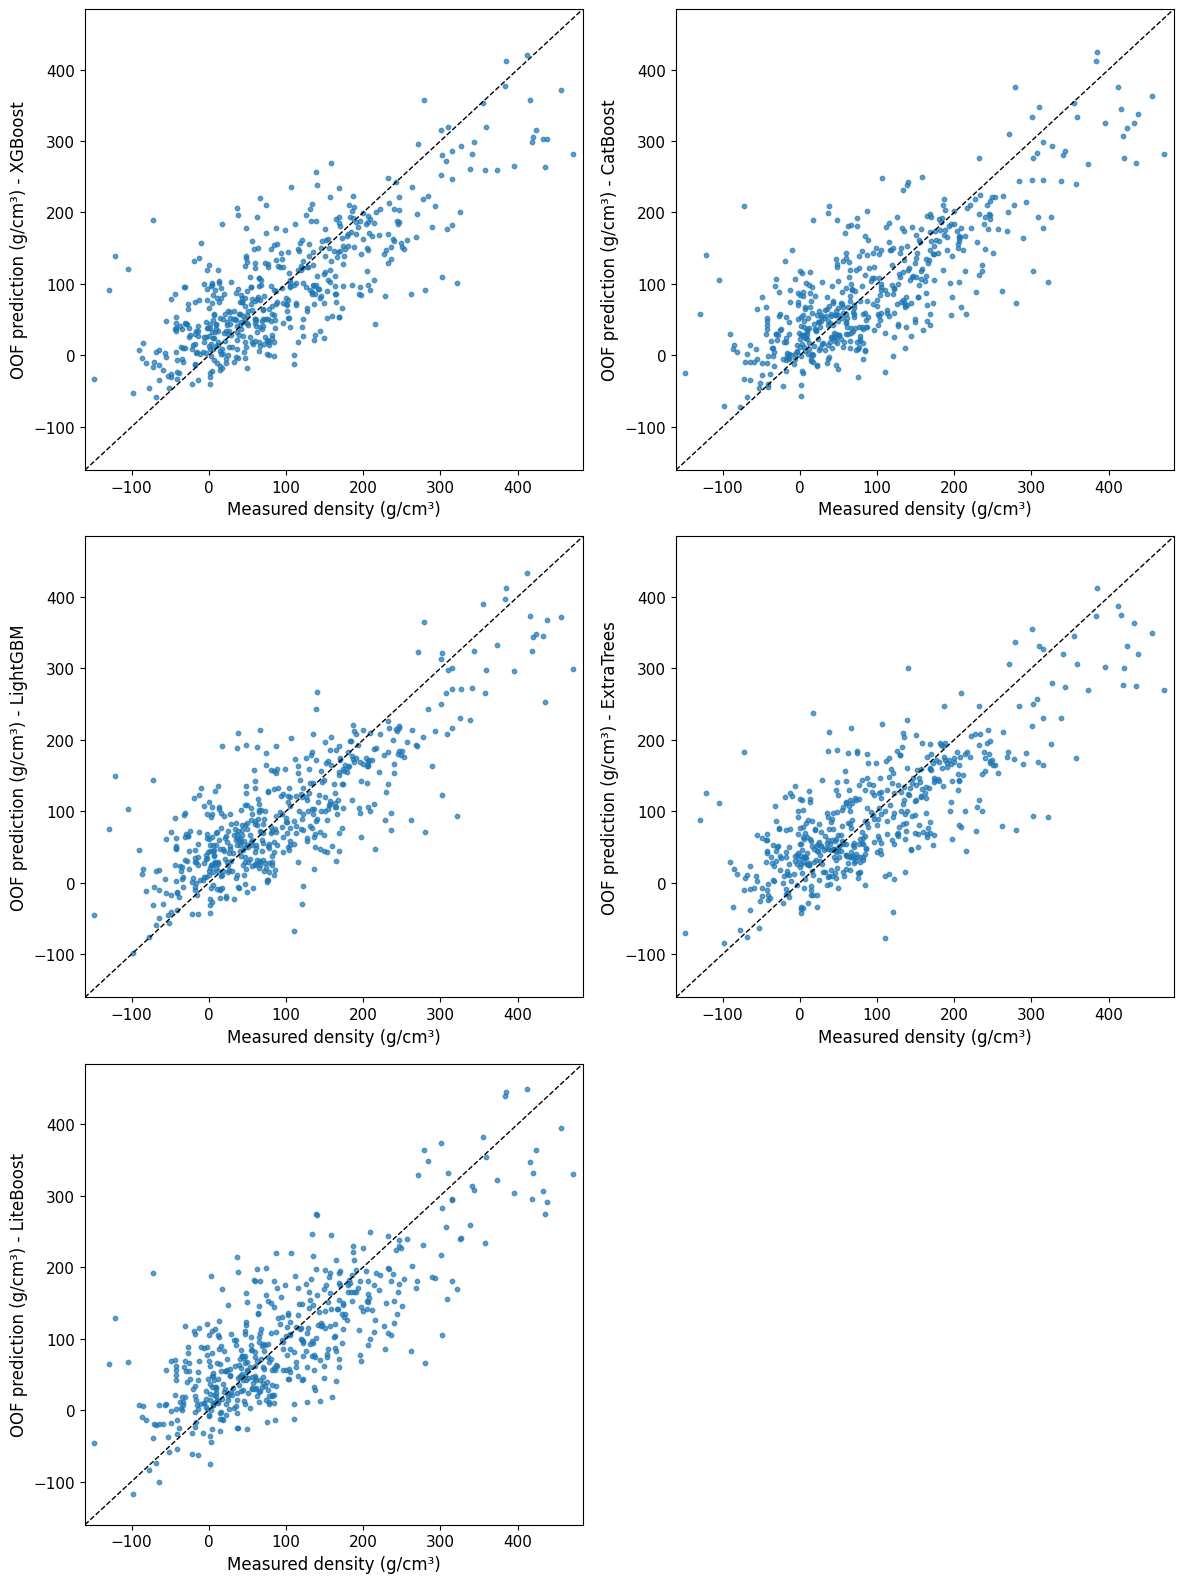

In [11]:
# OOF scatter plot of models predictions versus data
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.ravel()

ymin = float(min(y.min(), *(o.min() for o in all_oof.values())))
ymax = float(max(y.max(), *(o.max() for o in all_oof.values())))
pad = 0.02 * (ymax - ymin if ymax > ymin else 1.0)
lims = [ymin - pad, ymax + pad]

for i, name in enumerate(order):
    ax = axes[i]
    ax.scatter(y, all_oof[name], s=10, alpha=0.7)
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Measured density (g/cm³)")
    ax.set_ylabel(f"OOF prediction (g/cm³) - {name}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()